In [ ]:
from sklearn.datasets import load_diabetes
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
data = load_diabetes()
x = data.data
y = data.target

In [244]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size=0.1, random_state=42
)

In [245]:
#using euclidean distance formulla 
def euclidean_distance(point1,point2):
    return np.sqrt(np.sum((np.array(point1)-np.array(point2))**2))


In [246]:
def knn_predict(training_data,training_label,test_point,k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point,training_data[i])
        distances.append((dist,training_label[i]))
    distances.sort(key = lambda x: x[0])
    k_nearest_label = [label for _, label in distances[:k]]
    return Counter(k_nearest_label).most_common(1)[0][0]

In [247]:

k = 5

In [248]:
pred =knn_predict(x_train,y_train,x_test[0],k)
print("predicted value: ",pred)
print("actual value: ", y_test[0])


predicted value:  230.0
actual value:  219.0


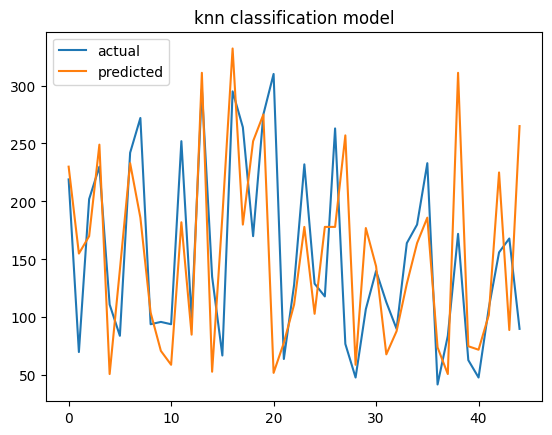

In [250]:
import matplotlib.pyplot as plt
prediction = [knn_predict(x_train,y_train,x_test[i],k) for i in range(len(x_test))]
plt.title("knn classification model")
plt.plot(y_test)
plt.plot(prediction)
plt.legend(['actual','predicted'])
plt.show()